First preparing data for training FFNN

In [3]:
import pandas as pd
import numpy as np
from model_functions.FFNN import FFNN
from sklearn.preprocessing import StandardScaler

train= pd.read_csv('claims_train.csv')
test = pd.read_csv('claims_test.csv')

#Cleaning weird values that found during cleaning
train = train[train['Exposure'] <= 1].copy()
test =test[test['Exposure']<=1].copy()

# Getting target column
y_train_np = train["ClaimNb"].to_numpy().reshape(-1, 1)
y_test_np  = test["ClaimNb"].to_numpy().reshape(-1, 1)
y_test=test['ClaimNb']

# Dropping correlated and useless columns
train=train.drop(columns=['IDpol', 'ClaimNb','Exposure'])
test=test.drop(columns=['IDpol', 'ClaimNb','Exposure'])

#Encoding
train_encoded=pd.get_dummies(train, columns=['VehBrand', 'VehGas', 'Region'], drop_first=True)#Encoding categorical values
area_map={'A':1,'B':2,'C':3,'D':4,'E':5,'F':6}
train_encoded['Area']=train_encoded['Area'].map(area_map)

test_encoded=pd.get_dummies(test, columns=['VehBrand', 'VehGas', 'Region'], drop_first=True)#Encoding categorical values
area_map={'A':1,'B':2,'C':3,'D':4,'E':5,'F':6}
test_encoded['Area']=test_encoded['Area'].map(area_map)

#Standarizing values
Scaler = StandardScaler()
train_encoded = Scaler.fit_transform(train_encoded)
test_encoded  = Scaler.transform(test_encoded)

X_train_np = np.asarray(train_encoded, dtype=float)
X_test_np  = np.asarray(test_encoded, dtype=float)




Time to use the self-made FFNN model. We decided it would makes sense to choose 64 neurons for first hidden layer and 32 for the second one

In [4]:

model=FFNN(input_size=38,hidden_sizes=[64,32],output_size=1, lr=0.0005)
model.fit(X=X_train_np,y=y_train_np,epochs=10, batch_size=1024)
y_pred=model.predict(X=X_test_np)

from sklearn.metrics import mean_poisson_deviance
poisson_dev = mean_poisson_deviance(y_test_np, y_pred)
print(f"Poisson Deviance: {poisson_dev:.4f}")

Epoch 0, Loss=0.3506974458928151
Epoch 1, Loss=0.28387181246621307
Epoch 2, Loss=0.22982886531006658
Epoch 3, Loss=0.23377666150054263
Epoch 4, Loss=0.21103487219374872
Epoch 5, Loss=0.21122008273968
Epoch 6, Loss=0.2303277247218792
Epoch 7, Loss=0.23637359156268697
Epoch 8, Loss=0.18349465754837535
Epoch 9, Loss=0.2379793459111563
Poisson Deviance: 0.3841


In [5]:
y_pred_flat = np.array(y_pred).reshape(-1)
df=pd.DataFrame({"y_test":y_test, "y_pred":y_pred_flat})
df["bucket"] = pd.qcut(df.y_pred, q=10, labels=False)
tab_FFNN=df.groupby("bucket")["y_test"].mean()
print(tab_FFNN)

bucket
0    0.052667
1    0.052006
2    0.054591
3    0.055625
4    0.060792
5    0.054296
6    0.050513
7    0.054533
8    0.051636
9    0.050894
Name: y_test, dtype: float64


Lift of Top 10 % compared to average

In [6]:
overall_mean=y_test.mean()
lift_FFNN= tab_FFNN.iloc[-1]/ overall_mean
print(lift_FFNN)

0.9467697874861497


Now we decided to do a classification view evaluation

In [7]:
from sklearn.metrics import precision_recall_curve, average_precision_score
y_true_bin= (y_test >0).astype(int)
y_true_bin[y_true_bin >0]

precision, recall, thresholds = precision_recall_curve(y_true_bin, y_pred)
ap_FFNN = average_precision_score(y_true_bin, y_pred)

print(ap_FFNN)

0.04970077467348


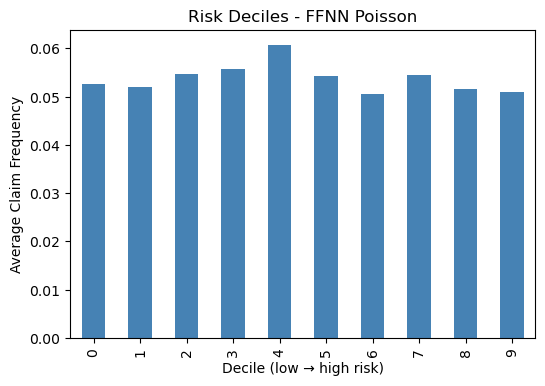

In [10]:
import matplotlib.pyplot as plt
def decile_plot(y_true, y_pred, model_name):
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df["decile"] = pd.qcut(df["y_pred"], 10, labels=False)

    deciles = df.groupby("decile")["y_true"].mean()

    plt.figure(figsize=(6,4))
    deciles.plot(kind="bar", color="steelblue")
    plt.title(f"Risk Deciles - {model_name}")
    plt.ylabel("Average Claim Frequency")
    plt.xlabel("Decile (low → high risk)")
    plt.show()
y_test_1d = y_test_np.reshape(-1)
decile_plot(y_test_1d, y_pred_flat, model_name= 'FFNN Poisson')

C:\Users\shere\AppData\Local\Temp\ipykernel_13988\669445038.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = df.groupby("bucket").agg(


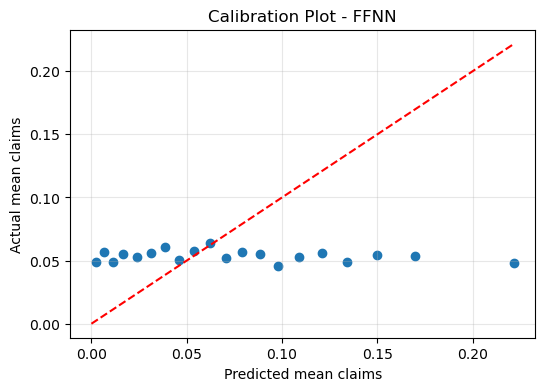

In [11]:
def calibration_plot(y_true, y_pred, model_name, bins=20):
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df["bucket"] = pd.qcut(df["y_pred"], bins, duplicates='drop')
    
    calib = df.groupby("bucket").agg(
        predicted=("y_pred","mean"),
        actual=("y_true","mean")
    )

    plt.figure(figsize=(6,4))
    plt.scatter(calib["predicted"], calib["actual"], label=model_name)
    max_val = max(calib["predicted"].max(), calib["actual"].max())
    plt.plot([0, max_val], [0, max_val], "r--")
    plt.xlabel("Predicted mean claims")
    plt.ylabel("Actual mean claims")
    plt.title(f"Calibration Plot - {model_name}")
    plt.grid(alpha=0.3)
    plt.show()
calibration_plot(y_test_1d, y_pred_flat, "FFNN")